# Compact representations of an existing equilibrium

A *generator* goes from parameters to an equilibrium, as
`solve_solovev_constraints`, `solve_guazzotto_freidberg` and CHEASE synthesis
do. A *compact representation* goes the other way: given an equilibrium, which
few numbers stand in for it, and how faithfully? This page covers the second
direction. Every fit reports its fidelity, and a poor fit is labelled
`poor_fidelity` rather than returned as if it were the equilibrium.

- **`fit_solovev`**: the Solov'ev solution closest to the flux map inside the
  LCFS, found by one linear least squares. It has a handful of coefficients
  and is an exact Grad–Shafranov solution by construction, but with constant
  sources.
- **`fit_mxh_chebyshev`**: the representation of Xie and Li
  (arXiv:2601.02942, 2026). Each surface $\rho = \sqrt{\psi_N}$ is an MXH shape,
  $R = R_0 + h + \rho a\cos\bar\theta$ and $Z = Z_0 + v + \kappa\rho a\sin\theta$,
  with $\bar\theta = \theta + c_0 + \sum_m (c_m\cos m\theta + s_m\sin m\theta)$.
  Every profile is a shifted-Chebyshev series in $\rho$ anchored at the LCFS.
  It is geometric only; no force balance is imposed.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from vaft.data.resources import sample_geqdsk
from vaft.process.equilibrium import (
    as_equilibrium, evaluate_mxh_chebyshev, evaluate_solovev, fit_mxh_chebyshev, fit_solovev,
    solovev_example, extract_flux_surface_contours,
)

reconstruction = as_equilibrium(sample_geqdsk())
analytic = solovev_example("single_null")
for name, eq in (("analytic single null", analytic), ("packaged reconstruction", reconstruction)):
    fit = fit_solovev(eq)
    shown = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in fit.metrics.items()}
    print(f"{name:24s} -> {fit.status:14s} {shown}")
exact = fit_solovev(analytic)
print(f"analytic sources: fitted p' = {exact.model.pprime:.6g}, true {2*np.pi*analytic.pprime[0]:.6g} Pa rad/Wb; "
      f"fitted FF' = {exact.model.ffprime:.6g}, true {2*np.pi*analytic.ffprime[0]:.6g} T^2 m^2 rad/Wb")

analytic single null     -> accepted       {'psi_rms_error': 0.0, 'psi_max_error': 0.0, 'grad_psi_rms_error': 0.0001, 'axis_displacement': 0.0, 'boundary_rms_error': 0.0015, 'boundary_max_error': 0.0203, 'topology_match': True}
packaged reconstruction  -> poor_fidelity  {'psi_rms_error': 0.0159, 'psi_max_error': 0.0504, 'grad_psi_rms_error': 0.1567, 'axis_displacement': 0.0332, 'boundary_rms_error': 0.0328, 'boundary_max_error': 0.0551, 'topology_match': True}


analytic sources: fitted p' = -77762.1, true -77762.1 Pa rad/Wb; fitted FF' = -0.140715, true -0.140715 T^2 m^2 rad/Wb


An exact Solov'ev input comes back exactly: the flux error is zero, the
topology matches, and the recovered $p'$ and $FF'$ are the true ones. The
reconstruction is not a constant-source equilibrium. Its best Solov'ev
stand-in misses the flux by 1.6 % of the span and the poloidal field by 16 %,
so it is reported as `poor_fidelity`. Its fitted $p'$ and $FF'$ are effective
values, not the reconstruction's.

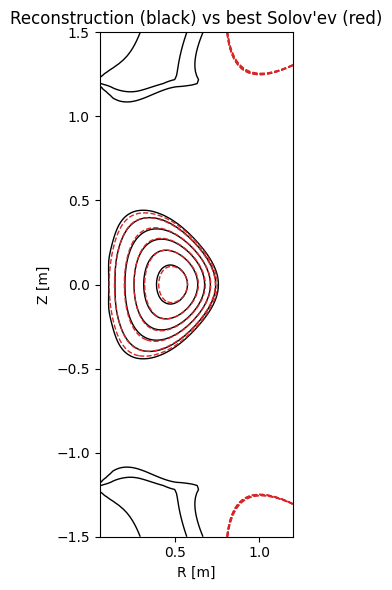

In [ ]:
fit = fit_solovev(reconstruction)
rm, zm = np.meshgrid(reconstruction.r, reconstruction.z, indexing="ij")
factor = 2 * np.pi if not reconstruction.convention.psi_per_radian else 1.0
span = (reconstruction.psi_boundary - reconstruction.psi_axis) / factor
psi_n = (reconstruction.psi / factor - reconstruction.psi_axis / factor) / span
psi_n_fit = (evaluate_solovev(fit.model, rm, zm, cocos=11)["psi"] - reconstruction.psi_axis / factor) / span
levels = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
fig, ax = plt.subplots(figsize=(4.8, 6))
ax.contour(reconstruction.r, reconstruction.z, psi_n.T, levels=levels, colors="k", linewidths=1)
ax.contour(reconstruction.r, reconstruction.z, psi_n_fit.T, levels=levels, colors="C3", linestyles="--", linewidths=1)
ax.set_aspect("equal"); ax.set(xlabel="R [m]", ylabel="Z [m]", title="Reconstruction (black) vs best Solov'ev (red)")
fig.tight_layout(); plt.show()

## MXH–Chebyshev: fidelity against the number of parameters

The representation has $(5 + 2M)(L+1)$ coefficients, for $M$ MXH harmonics and
Chebyshev order $L$. Xie and Li report $10^{-2}$–$10^{-3}$ accuracy with a few
tens of parameters. Here that is measured on the reconstruction's own flux map
as $\psi_N(R, Z) - \rho^2$ on the represented surfaces.

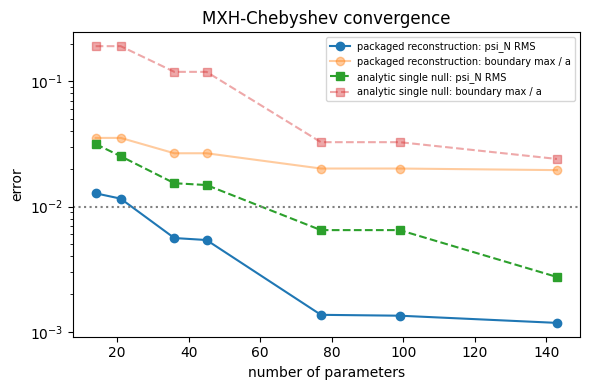

In [ ]:
orders = [(1, 1), (1, 2), (2, 3), (2, 4), (3, 6), (3, 8), (4, 10)]
fig, ax = plt.subplots(figsize=(6, 4))
for name, eq, style in (("packaged reconstruction", reconstruction, "o-"), ("analytic single null", analytic, "s--")):
    counts, errors, boundary = [], [], []
    for m, l in orders:
        rep = fit_mxh_chebyshev(eq, harmonics=m, radial_order=l)
        counts.append(rep.parameter_count); errors.append(rep.metrics["psi_n_rms_error"])
        boundary.append(rep.metrics["boundary_max_error"])
    ax.semilogy(counts, errors, style, label=f"{name}: psi_N RMS")
    ax.semilogy(counts, boundary, style, alpha=0.4, label=f"{name}: boundary max / a")
ax.axhline(1e-2, color="grey", ls=":"); ax.set(xlabel="number of parameters", ylabel="error",
                                               title="MXH-Chebyshev convergence")
ax.legend(fontsize=7); fig.tight_layout(); plt.show()

On the single null, the boundary error is the last to converge. A low-order
MXH shape cannot follow the X-point corner, and the fit reports that rather
than hiding it. It only reaches the reconstruction's level at the highest
orders, while the interior converges from the start.

## What the coefficients mean

The radial profiles have direct geometric meaning. $h(\rho)$ is the Shafranov
shift of the surface centres, $\kappa(\rho)$ the elongation, and $s_1(\rho)$
the triangularity ($\delta \approx \sin s_1$). They are the compact state
vector that a database or surrogate model would consume.

status accepted, 45 parameters, metrics: {'psi_n_rms_error': 0.0054, 'psi_n_max_error': 0.0395, 'boundary_rms_error': 0.0124, 'boundary_max_error': 0.0267, 'surface_shape_max_rms_error': 0.0125, 'axis_displacement': 0.0115}


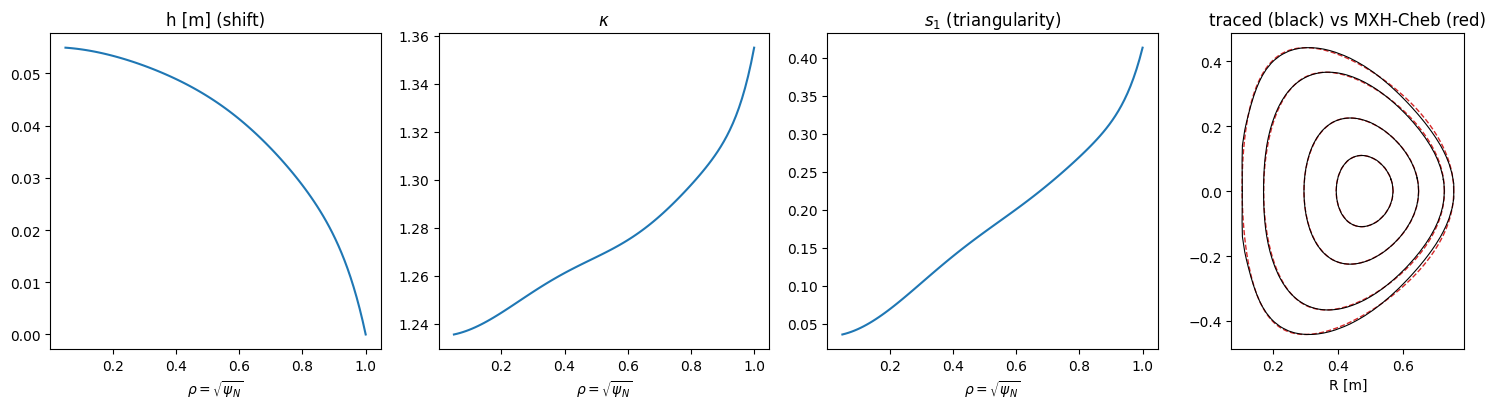

In [ ]:
rep = fit_mxh_chebyshev(reconstruction, harmonics=2, radial_order=4)
print(f"status {rep.status}, {rep.parameter_count} parameters, metrics:",
      {k: round(v, 4) for k, v in rep.metrics.items()})
rho = np.linspace(0.05, 1, 100)
from vaft.process._equilibrium_compact import _radial_basis
basis = _radial_basis(rho, rep.radial_order)
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), gridspec_kw={"width_ratios": [1, 1, 1, 0.8]})
for ax, name, label in zip(axes[:3], ("h", "kappa", "s1"), ("h [m] (shift)", r"$\kappa$", r"$s_1$ (triangularity)")):
    edge, coefficients = rep.profiles[name]
    ax.plot(rho, edge + basis @ np.asarray(coefficients)); ax.set(xlabel=r"$\rho=\sqrt{\psi_N}$", title=label)
theta = np.linspace(0, 2 * np.pi, 200)
for level in (0.3, 0.6, 0.9, 1.0):
    r_rep, z_rep = evaluate_mxh_chebyshev(rep, np.full_like(theta, level), theta)
    axes[3].plot(r_rep, z_rep, "C3--", lw=1)
traced = extract_flux_surface_contours(reconstruction.psi, reconstruction.r, reconstruction.z,
                                       reconstruction.psi_axis, reconstruction.psi_boundary, [0.09, 0.36, 0.81])
box = (reconstruction.lcfs.r.min(), reconstruction.lcfs.r.max(), reconstruction.lcfs.z.min(), reconstruction.lcfs.z.max())
for segments in traced.values():
    for r_seg, z_seg in segments:
        if box[0] <= np.min(r_seg) and np.max(r_seg) <= box[1] and box[2] <= np.min(z_seg) and np.max(z_seg) <= box[3]:
            axes[3].plot(r_seg, z_seg, "k-", lw=0.8)   # plasma surfaces only, not saddles near the coils
axes[3].plot(reconstruction.lcfs.r, reconstruction.lcfs.z, "k-", lw=0.8)
axes[3].set_aspect("equal"); axes[3].set(xlabel="R [m]", title="traced (black) vs MXH-Cheb (red)")
fig.tight_layout(); plt.show()